In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("car_data.csv")


In [6]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [9]:
 # How many rows and columns are in the dataset?
df.shape

(301, 9)

In [12]:
#What are the data types of each column?
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [13]:
#Are there any missing values in the dataset?
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [15]:
#Are there any duplicate records?
df.duplicated().sum()

np.int64(2)

In [18]:
#Unique values in Fuel_Type, Seller_Type, Transmission
{
    "Fuel_Type": df["Fuel_Type"].unique(),
    "Seller_Type": df["Seller_Type"].unique(),
    "Transmission": df["Transmission"].unique()
}


{'Fuel_Type': array(['Petrol', 'Diesel', 'CNG'], dtype=object),
 'Seller_Type': array(['Dealer', 'Individual'], dtype=object),
 'Transmission': array(['Manual', 'Automatic'], dtype=object)}

In [28]:
#Average, max, and min Selling_Price?
df["Selling_Price"].mean(),df["Selling_Price"].max(),df["Selling_Price"].min()


(np.float64(4.661295681063123), 35.0, 0.1)

In [29]:
#Average Selling_Price by Fuel_Type?
df.groupby("Fuel_Type")["Selling_Price"].mean()


Fuel_Type
CNG        3.100000
Diesel    10.278500
Petrol     3.264184
Name: Selling_Price, dtype: float64

In [24]:
#Average Selling_Price by Transmission type?
df["Car_Name"].value_counts().head(1)


Car_Name
city    26
Name: count, dtype: int64

In [25]:
#Which car model appears most frequently?
df["Car_Name"].value_counts().head(1)


Car_Name
city    26
Name: count, dtype: int64

In [26]:
#Average Selling_Price for each car model?
df.groupby("Car_Name")["Selling_Price"].mean()


Car_Name
800                  0.350000
Activa 3g            0.310000
Activa 4g            0.400000
Bajaj  ct 100        0.180000
Bajaj Avenger 150    0.750000
                       ...   
sx4                  3.158333
verna                6.107857
vitara brezza        9.250000
wagon r              2.512500
xcent                4.966667
Name: Selling_Price, Length: 98, dtype: float64

In [27]:
#Range of years (min and max Year)?
df["Year"].min(), df["Year"].max()


(2003, 2018)

In [30]:
#Average Selling_Price grouped by Year?
df.groupby("Year")["Selling_Price"].mean()


Year
2003    1.300000
2004    1.500000
2005    2.487500
2006    1.437500
2007    0.160000
2008    1.002857
2009    2.816667
2010    5.262667
2011    2.375263
2012    3.841304
2013    3.540909
2014    4.762105
2015    5.927049
2016    5.213200
2017    6.209143
2018    9.250000
Name: Selling_Price, dtype: float64

In [35]:
#Most common number of owners?
df["Owner"].value_counts().head(1)


Owner
0    290
Name: count, dtype: int64

In [36]:
#Average number of kilometers driven?
df["Kms_Driven"].mean()


np.float64(36947.20598006644)

In [37]:
#Which car has the highest Present_Price?
df.loc[df["Present_Price"].idxmax()]



Car_Name         land cruiser
Year                     2010
Selling_Price            35.0
Present_Price            92.6
Kms_Driven              78000
Fuel_Type              Diesel
Seller_Type            Dealer
Transmission           Manual
Owner                       0
Name: 86, dtype: object

In [38]:
#Correlation between Selling_Price, Present_Price, and Kms_Driven?
df[["Selling_Price","Present_Price","Kms_Driven"]].corr()


,Selling_Price,Present_Price,Kms_Driven
Selling_Price,1.000000,0.878983,0.029187
Present_Price,0.878983,1.000000,0.203647
Kms_Driven,0.029187,0.203647,1.000000


In [39]:
#Seller_Type with highest average Selling_Price?
df.groupby("Seller_Type")["Selling_Price"].mean().sort_values(ascending=False)


Seller_Type
Dealer        6.721692
Individual    0.870943
Name: Selling_Price, dtype: float64

In [40]:
#How many cars are there of each Fuel_Type?
df["Fuel_Type"].value_counts()


Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [42]:
#How many cars have more than one previous owner?
(df["Owner"] > 1).sum()


np.int64(1)

In [43]:
#Top 5 most expensive cars (by Selling_Price)?
df.nlargest(5, "Selling_Price")


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
86,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0
64,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0
63,fortuner,2015,23.5,35.96,47000,Diesel,Dealer,Automatic,0
51,fortuner,2015,23.0,30.61,40000,Diesel,Dealer,Automatic,0
82,innova,2017,23.0,25.39,15000,Diesel,Dealer,Automatic,0


In [44]:
#Average difference between Present_Price and Selling_Price?
(df["Present_Price"] - df["Selling_Price"]).mean()


np.float64(2.967176079734219)

In [45]:
#How many cars are being sold by individual sellers vs dealers?
df["Seller_Type"].value_counts()


Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [46]:
#How many cars were manufactured before 2010?
(df["Year"] < 2010).sum()


np.int64(26)

In [47]:
#Which year has the highest number of car listings?
df["Year"].value_counts().head(1)


Year
2015    61
Name: count, dtype: int64

In [48]:
#Percentage of cars using Diesel, Petrol, CNG?
df["Fuel_Type"].value_counts(normalize=True) * 100


Fuel_Type
Petrol    79.401993
Diesel    19.933555
CNG        0.664452
Name: proportion, dtype: float64

In [49]:
#Highest and lowest Kms_Driven for each Fuel_Type?
df.groupby("Fuel_Type")["Kms_Driven"].agg(["min","max"])


,min,max
Fuel_Type,,
CNG,35500,49998
Diesel,2071,197176
Petrol,500,500000


In [51]:
#How many cars were sold with exactly 0 previous owners?
(df["Owner"] == 0).sum()


np.int64(290)

In [52]:
#Unique combinations of Fuel_Type, Seller_Type, Transmission?
df[["Fuel_Type","Seller_Type","Transmission"]].drop_duplicates().shape[0]


8

In [54]:
#Average Selling_Price of cars with more than 2 previous owners?
df.loc[df["Owner"] > 2, "Selling_Price"].mean()


np.float64(2.5)

In [19]:
df.replace({
    "Fuel_Type": {"Petrol": 0, "Diesel": 1, "CNG": 2},
    "Seller_Type": {"Dealer": 0, "Individual": 1},
    "Transmission": {"Manual": 0, "Automatic": 1}
}, inplace=True)

C:\Users\Sai\AppData\Local\Temp\ipykernel_47728\1874595546.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


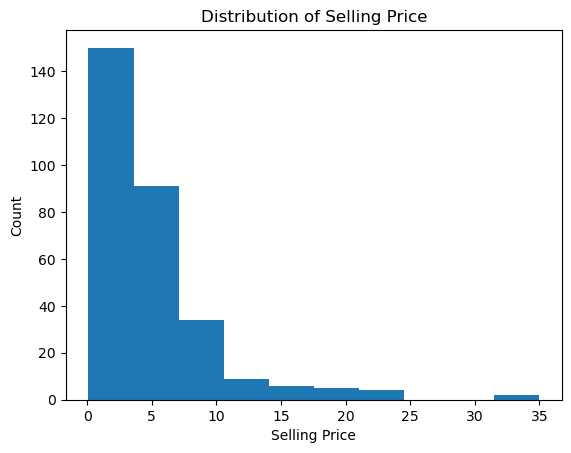

In [9]:
#Selling Price Distribution
plt.hist(df["Selling_Price"])
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.title("Distribution of Selling Price")
plt.show()


Most cars are sold in lower price range, few premium cars exist.

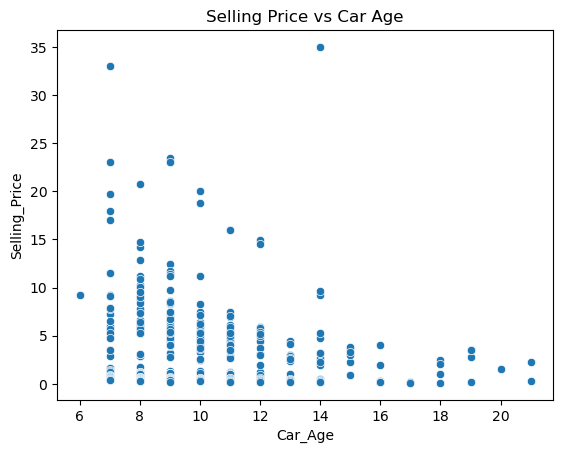

In [10]:
#Selling Price vs Car Age
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Selling Price vs Car Age")
plt.show()


As car age increases, selling price decreases → strong negative trend.

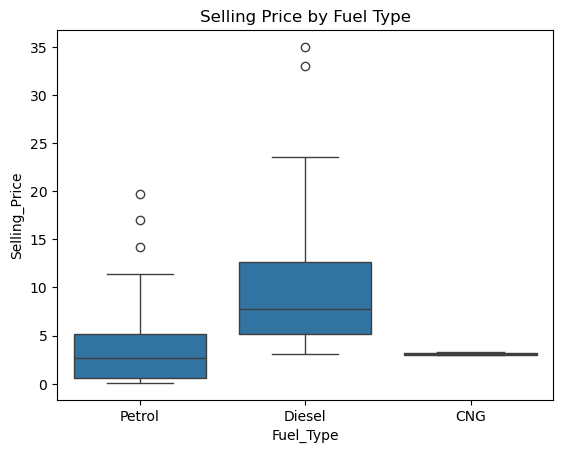

In [11]:
#Fuel Type vs Selling Price
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Selling Price by Fuel Type")
plt.show()


Diesel cars usually have higher resale value than petrol.

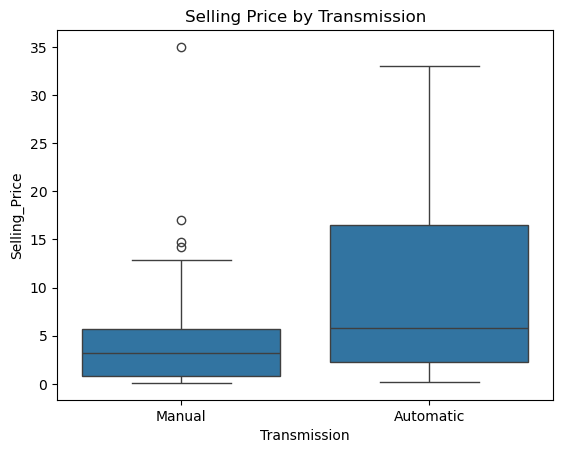

In [12]:
#Transmission vs Selling Price
sns.boxplot(x="Transmission", y="Selling_Price", data=df)
plt.title("Selling Price by Transmission")
plt.show()


Automatic cars tend to sell at higher prices.

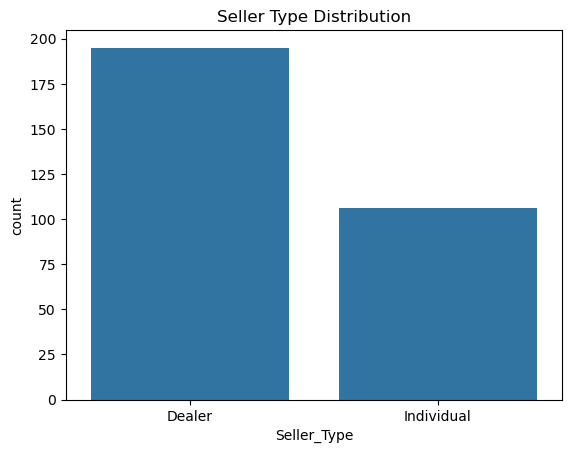

In [13]:
#Seller Type Analysis
sns.countplot(x="Seller_Type", data=df)
plt.title("Seller Type Distribution")
plt.show()


Most cars are sold by individual sellers, not dealers.

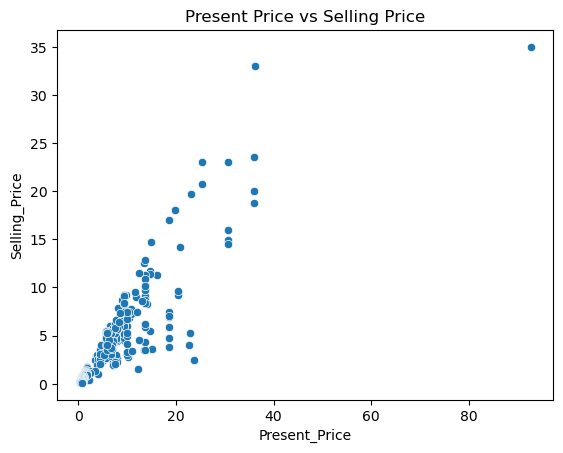

In [15]:
#Present Price vs Selling Price
sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)
plt.title("Present Price vs Selling Price")
plt.show()


Cars with higher original price tend to have higher resale value.

In [22]:
import seaborn as sns

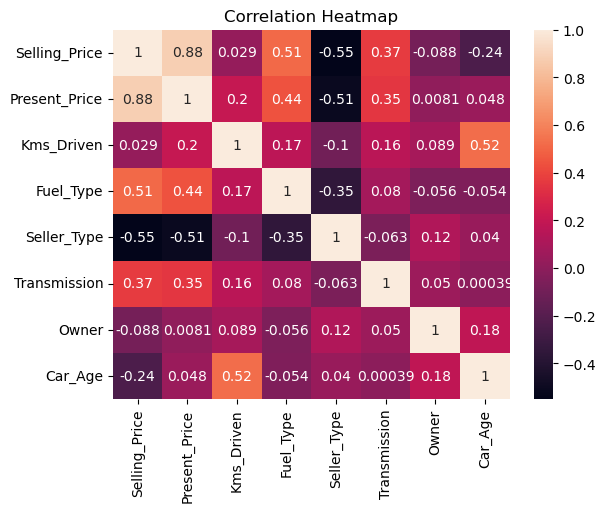

In [31]:
#Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


Selling price strongly depends on:

  1)Present price

  2)Car age

Mileage has weaker influence

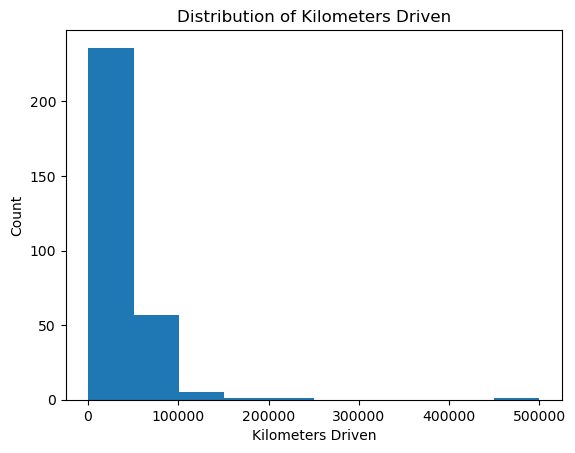

In [25]:
#Mileage (Kms_Driven) Distribution
plt.hist(df["Kms_Driven"])
plt.xlabel("Kilometers Driven")
plt.ylabel("Count")
plt.title("Distribution of Kilometers Driven")
plt.show()


Most cars have lower to moderate mileage

Few cars have very high usage (outliers)

Helps understand wear & tear impact on price

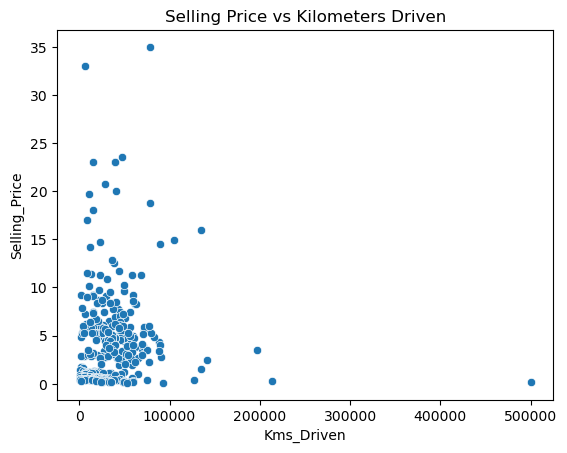

In [26]:
#Kms Driven vs Selling Price
sns.scatterplot(x="Kms_Driven", y="Selling_Price", data=df)
plt.title("Selling Price vs Kilometers Driven")
plt.show()


Cars driven more tend to sell at lower prices

Negative relationship between usage and resale value

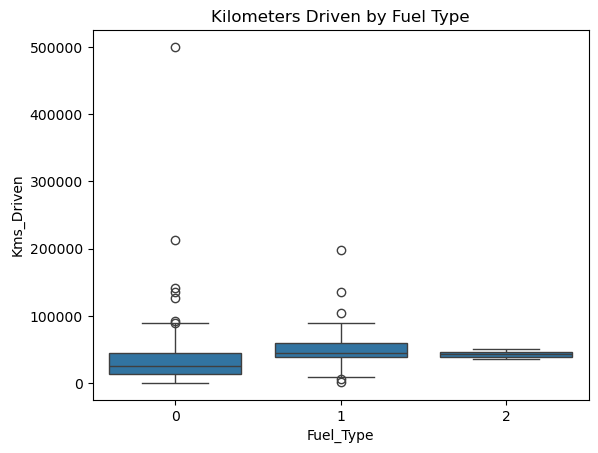

In [27]:
#Fuel Type vs Kilometers Driven
sns.boxplot(x="Fuel_Type", y="Kms_Driven", data=df)
plt.title("Kilometers Driven by Fuel Type")
plt.show()


Diesel cars usually have higher usage

Petrol cars are generally driven less

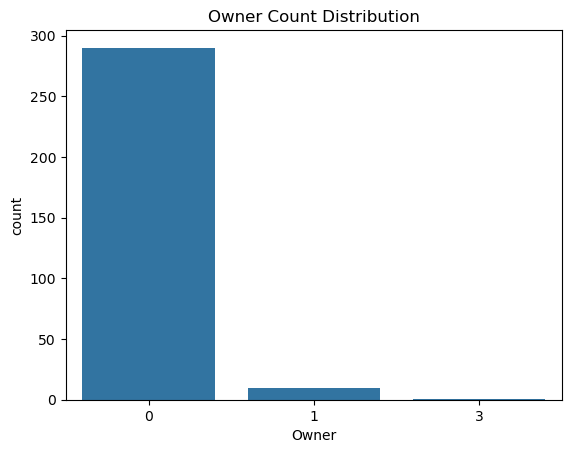

In [28]:
#Owner Count Analysis
sns.countplot(x="Owner", data=df)
plt.title("Owner Count Distribution")
plt.show()


Majority cars are first-owner

Dataset favors better-maintained vehicles

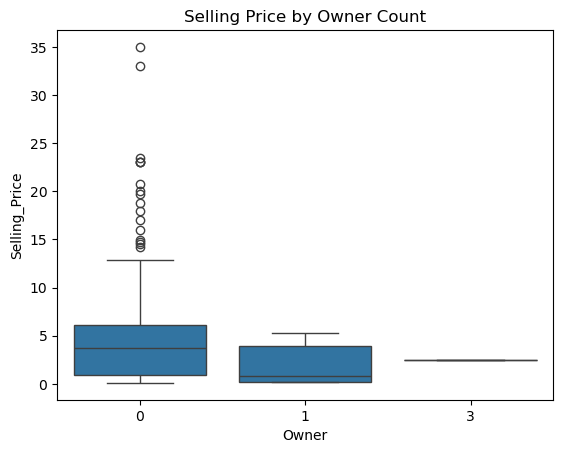

In [29]:
#Owner vs Selling Price
sns.boxplot(x="Owner", y="Selling_Price", data=df)
plt.title("Selling Price by Owner Count")
plt.show()

First-owner cars have highest resale value

Price decreases as owner count increases

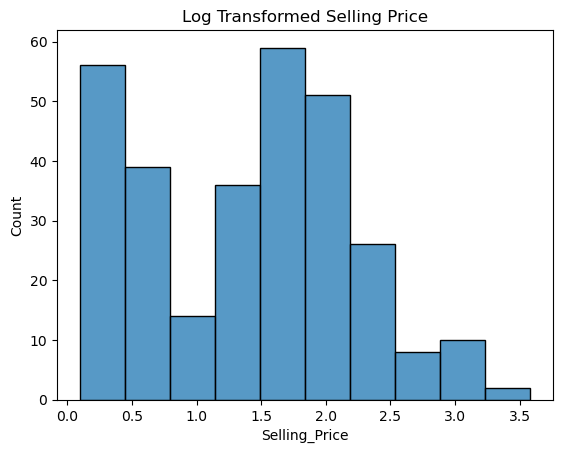

In [30]:
sns.histplot(np.log1p(df["Selling_Price"]))
plt.title("Log Transformed Selling Price")
plt.show()


Reduces skewness

Makes data suitable for regression models

STRONG INSIGHTS 

Selling price decreases with:

  1)Increase in car age

  2)Increase in kilometers driven

Diesel & automatic cars retain higher value

First-owner cars dominate the dataset

Dealer pricing is generally higher than individuals

Dataset is not highly skewed after transformation